# Permutation Tests

Train and evaluate model families after optionally permuting graph targets and/or marker features within each organoid.

This notebook follows the current experiment conventions used by the newer analysis notebooks: `after_cleanup` by default, explicit filtering toggles, saved settings, and replot-friendly result tables.


In [20]:
import copy
import inspect
import json
import math
import pickle
import random
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT / "training_data"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())


PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


In [21]:
# Data and target settings
EXPERIMENT_GROUP = "permutation_tests"
DATASET_NAME = "after_cleanup"
TARGET_INDICES = [0]
USE_GLOBAL_FEATURES = True

# Filtering and preprocessing settings
TIMEPOINT_FILTER_MODE = "rest"  # "rest", "day3p5", or "all"
DAY3P5_TIMEPOINT = "day3p5"
FILTER_BLACKLISTED_ORGANOIDS = True

# The after_cleanup dataset no longer relies on the old complexity filter.
FILL_MISSING_COMPLEXITY = False
APPLY_COMPLEXITY_FILTER = False
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
COMPLEXITY_MIN = None  # e.g. 2.0 for older datasets with complexity metadata

SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split and permutation settings
VAL_FRAC = 0.2
SPLIT_SEED = 0
FORCED_VAL_KEYS = set()
PERMUTE_TARGETS = False
PERMUTE_FEATURES = True
PERMUTATION_SEED = 0

# Model settings
MODEL_FAMILIES = ["GIN", "ring", "ring-size"]
K_MAX = 5
DEPTHS = np.arange(0, K_MAX)
BASE_HIDDEN_DIM = 4 * 64
BASE_DROPOUT = 0.1
BASE_NORM = "batch"

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 1000
PATIENCE = 30
NUM_WORKERS = 4

# Experiment output settings
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = (
    f"{DATASET_NAME}_{TIMEPOINT_FILTER_MODE}_"
    f"targets-{int(PERMUTE_TARGETS)}_features-{int(PERMUTE_FEATURES)}_"
    f"depths-{'-'.join(map(str, DEPTHS.tolist()))}_{RUN_TIMESTAMP}"
)
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"
TABLES_DIR = SAVE_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


def set_all_seeds(seed):
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


set_all_seeds(SPLIT_SEED)


In [22]:
def _safe_filename(name):
    text = str(name).strip().replace("/", "_")
    chars = [ch if (ch.isalnum() or ch in "._-") else "_" for ch in text]
    cleaned = "".join(chars).strip("._-")
    while "__" in cleaned:
        cleaned = cleaned.replace("__", "_")
    return cleaned or "figure"


def jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, (torch.dtype, np.dtype)):
        return str(obj)
    return obj


def save_mpl_figure(fig, name, *, close=False, dpi=300):
    stem = _safe_filename(name)
    saved_paths = []
    for suffix in ("pdf", "png"):
        path = FIGURES_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", transparent=True, dpi=dpi)
        saved_paths.append(path)
    print(f"Saved figure -> {saved_paths[0]}")
    if close:
        plt.close(fig)
    return saved_paths


def save_current_mpl_figure(name, *, close=False):
    return save_mpl_figure(plt.gcf(), name, close=close)


def save_plotly_figure(fig, name, *, scale=2):
    path = FIGURES_DIR / f"{_safe_filename(name)}.png"
    try:
        fig.write_image(str(path), scale=scale)
        print(f"Saved Plotly figure -> {path}")
    except Exception as exc:
        print(f"Could not save Plotly figure as PNG at {path}: {exc}")
    return path


In [23]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    attach_metadata_to_graphs,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
)

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")
if graphs:
    print("Raw y shape:", tuple(graphs[0].y.shape))

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
if graphs:
    print("Selected y shape:", tuple(graphs[0].y.shape))

marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]
print(f"Loaded {len(marker_names)} markers.")

print_graph_and_metadata_fields(graphs)


Loaded 1500 graphs; skipped 0.
Loaded 1500 organoids.
Raw y shape: (165, 2)
Attached metadata to 1500/1500 graphs.
Selected y shape: (165,)
Loaded 7 markers.
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


In [24]:
from src.data.filters import (
    filter_graphs_by_blacklist,
    filter_graphs_by_metadata,
    load_graph_blacklist_from_dir,
)

if TIMEPOINT_FILTER_MODE == "rest":
    graphs = filter_graphs_by_metadata(
        graphs,
        key="timepoint",
        drop_values={DAY3P5_TIMEPOINT},
        missing="keep",
        inplace=False,
        print_summary=True,
    )
elif TIMEPOINT_FILTER_MODE == "day3p5":
    graphs = filter_graphs_by_metadata(
        graphs,
        key="timepoint",
        keep_values={DAY3P5_TIMEPOINT},
        missing="drop",
        inplace=False,
        print_summary=True,
    )
elif TIMEPOINT_FILTER_MODE not in (None, "all"):
    raise ValueError('TIMEPOINT_FILTER_MODE must be "rest", "day3p5", or "all".')

if FILTER_BLACKLISTED_ORGANOIDS:
    blacklist = load_graph_blacklist_from_dir(data_dir)
    graphs = filter_graphs_by_blacklist(graphs, blacklist, print_summary=True)
else:
    blacklist = set()


filter_graphs_by_metadata(key='timepoint'): kept 1210 / 1500 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5                0    290    0.000
20250929         day4                342    342    1.000
20250929         day4p5              113    113    1.000
20250929         day4p5-more         477    477    1.000
20251201         day4p5              278    278    1.000
filter_graphs_by_blacklist(n_keys=17): kept 1193 / 1210 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                330    342    0.965
20250929         day4p5              112    113    0.991
20250929         day4p5-more         475    477    0.996
20251201         day4p5              276    278    0.993


In [25]:
from src.data.metadata import fill_missing_metadata_for_group
from src.data.filters import (
    filter_graphs_by_marker_diversity,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

if FILL_MISSING_COMPLEXITY:
    graphs = fill_missing_metadata_for_group(
        graphs,
        field="complexity",
        fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
        dataset=MISSING_COMPLEXITY_GROUP["dataset"],
        timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
    )
else:
    print("Skipping missing-complexity fill.")

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)

g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)

if APPLY_COMPLEXITY_FILTER:
    if COMPLEXITY_MIN is None:
        raise ValueError("COMPLEXITY_MIN must be set when APPLY_COMPLEXITY_FILTER=True.")
    graphs = filter_graphs_by_numeric_metadata(
        graphs,
        key="complexity",
        min_value=COMPLEXITY_MIN,
        allow_missing=False,
        inplace=False,
        print_summary=True,
    )
else:
    print("Skipping complexity filter; after_cleanup does not include complexity metadata.")

# graphs = graphs + g_spherical
print(f"After filtering and spherical rescue: {len(graphs)} organoids.")

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        target_indices=None,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None


Skipping missing-complexity fill.
filter_graphs_by_sphericity(max_sphericity=0.92): kept 811 / 1193 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                216    330    0.655
20250929         day4p5               88    112    0.786
20250929         day4p5-more         322    475    0.678
20251201         day4p5              185    276    0.670
filter_graphs_by_marker_diversity(min_score=0.5, top_k=None): kept 136 / 382 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                 48    114    0.421
20250929         day4p5               16     24    0.667
20250929         day4p5-more          44    153    0.288
20251201         day4p5               28     91    0.308
Skipping complexity filter; after_cleanup does not include complexity metadata.
After filtering and spherical rescue: 8

In [26]:
from src.data.metadata import add_log_metadata_features, promote_metadata_to_graph_tensors

field_specs = [
    {
        "meta_keys": [
            "log_surface_area",
            "log_volume",
            "log_volume_over_area",
            "log_num_cells",
        ],
        "attr_name": "global_feat",
        "kind": "graph_vector",
        "dtype": torch.float32,
    },
]

if USE_GLOBAL_FEATURES:
    graphs = add_log_metadata_features(graphs, inplace=False)
    graphs = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)
    print("Promoted metadata fields to graph tensor attributes.")
else:
    print("Global features disabled; no global_feat attribute was attached.")


Promoted metadata fields to graph tensor attributes.


In [27]:
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.metadata import infer_global_dim, snapshot_graph_metadata, strip_graph_metadata
from src.data.target_transforms import AsinhStandardizeTransform, standardize_graph_global_features

g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    force_val_keys=FORCED_VAL_KEYS,
    key_fn=graph_metadata_key,
)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

val_meta_lookup = snapshot_graph_metadata(g_val)

g_train = strip_graph_metadata(g_train, inplace=False)
g_val = strip_graph_metadata(g_val, inplace=False)

target_transform = AsinhStandardizeTransform(robust=True).fit(g_train)
target_transform.transform_graphs(g_train)
target_transform.transform_graphs(g_val)

center_global, scale_global = None, None
if USE_GLOBAL_FEATURES:
    center_global, scale_global = standardize_graph_global_features(
        g_train,
        g_val,
        attr_name="global_feat",
        robust=False,
    )

global_dim = infer_global_dim(g_train)
print("global_dim =", global_dim)


Split -> train: 649 | val: 162
global_dim = 4


In [28]:
from src.data.permutation import (
    permute_graph_features_within_organoid,
    permute_graph_targets_within_organoid,
)

permutation_generator = torch.Generator(device="cpu")
permutation_generator.manual_seed(int(PERMUTATION_SEED))

if PERMUTE_TARGETS:
    g_train = permute_graph_targets_within_organoid(
        g_train,
        inplace=False,
        generator=permutation_generator,
    )
    g_val = permute_graph_targets_within_organoid(
        g_val,
        inplace=False,
        generator=permutation_generator,
    )

if PERMUTE_FEATURES:
    g_train = permute_graph_features_within_organoid(
        g_train,
        inplace=False,
        generator=permutation_generator,
    )
    g_val = permute_graph_features_within_organoid(
        g_val,
        inplace=False,
        generator=permutation_generator,
    )


In [29]:
print("target_transform =", target_transform.name)


target_transform = asinh_standardize


In [30]:
from src.training.loop import TrainConfig, train

cfg = TrainConfig(
    loss_name="gaussian",
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")


In [31]:
from src.data.ring_features import attach_precomputed_ring_features

g_train = attach_precomputed_ring_features(
    g_train,
    k_hops=K_MAX,
    inplace=False,
)

g_val = attach_precomputed_ring_features(
    g_val,
    k_hops=K_MAX,
    inplace=False,
)


In [32]:
from src.models.gnn import GINCurvature
from src.models.ring_mlp import RingFractionMLP, PooledKHopMLP, RingSizeMLP
from src.data.metadata import infer_global_dim

depths = DEPTHS
base_hidden_dim = BASE_HIDDEN_DIM
base_dropout = BASE_DROPOUT
base_norm = BASE_NORM

trained_model_families = {family: [] for family in MODEL_FAMILIES}

param_rows = []

for family in trained_model_families.keys():

    for k in depths:
        print(f"\n=== Training {family} model with depth={k} ===")

        n_markers = int(g_train[0].x.size(1))
        global_dim = infer_global_dim(g_train)

        if family == "GIN":
            model_kwargs = {
                "n_markers": n_markers,
                "hidden_dim": base_hidden_dim,
                "num_layers": int(k),
                "dropout": base_dropout,
                "residual": True,
                "norm": base_norm,
                "train_eps": True,
                "global_dim": global_dim,
            }
            model = GINCurvature(**model_kwargs)


        elif family == "ring":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
                "feature_attr": "x_ring",
                "global_dim": global_dim,
            }
            model = RingFractionMLP(**model_kwargs)

        elif family == "ring-size":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
                "global_dim": global_dim,
            }
            model = RingSizeMLP(**model_kwargs)

        elif family == "ring-size (no center)":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
                "use_center_markers": False,
                "global_dim": global_dim,
            }
            model = RingSizeMLP(**model_kwargs)

        else:
            raise ValueError(f"Unknown family: {family}")

        model, metrics, history = train(model, g_train, g_val, cfg)
        trained_model_families[family].append(model)
        param_rows.append({
            "family": family,
            "depth": int(k),
            "model_kwargs": jsonable(model_kwargs),
            "metrics": jsonable(metrics),
            "best_epoch": jsonable(getattr(history, "best_epoch", None)),
            "history_length": len(history) if hasattr(history, "__len__") else None,
        })


=== Training GIN model with depth=0 ===
epoch 001 | train loss 0.5272 mae 0.7849 | val loss 0.5003 mae 0.7758
epoch 002 | train loss 0.4964 mae 0.7727 | val loss 0.4814 mae 0.7670
epoch 003 | train loss 0.4805 mae 0.7639 | val loss 0.4698 mae 0.7603
epoch 004 | train loss 0.4694 mae 0.7573 | val loss 0.4618 mae 0.7555
epoch 005 | train loss 0.4623 mae 0.7528 | val loss 0.4546 mae 0.7519
epoch 006 | train loss 0.4564 mae 0.7497 | val loss 0.4484 mae 0.7501
epoch 007 | train loss 0.4511 mae 0.7480 | val loss 0.4425 mae 0.7490
epoch 008 | train loss 0.4460 mae 0.7461 | val loss 0.4364 mae 0.7474
epoch 009 | train loss 0.4413 mae 0.7449 | val loss 0.4310 mae 0.7461
epoch 010 | train loss 0.4372 mae 0.7439 | val loss 0.4262 mae 0.7452
epoch 011 | train loss 0.4334 mae 0.7432 | val loss 0.4217 mae 0.7447
epoch 012 | train loss 0.4296 mae 0.7426 | val loss 0.4174 mae 0.7441
epoch 013 | train loss 0.4261 mae 0.7421 | val loss 0.4135 mae 0.7439
epoch 014 | train loss 0.4233 mae 0.7417 | val lo

In [33]:
from src.analysis.prediction_analysis import eval_model_per_marker

def evaluate_family_models(trained_models, eval_subgraphs, device, target_transform):
    all_results = {}

    aggregate_keys = ["any_marker", "no_marker", "all_nodes"]
    aggregate_metric_keys = [
        "n",
        "mse_model", "sem_mse_model",
        "mse_base", "sem_mse_base",
        "var_model", "sem_var_model",
        "var_base", "sem_var_base",
        "nll_model", "sem_nll_model",
        "nll_base", "sem_nll_base",
        "rho", "pval",
    ]

    for family, models in trained_models.items():
        fam_mse_model = []
        fam_sem_mse_model = []
        fam_var_model = []
        fam_sem_var_model = []
        fam_nll_model = []
        fam_sem_nll_model = []
        fam_rho_marker = []
        fam_pval_marker = []
        fam_n_pos_corr = []
        fam_rho_global = []
        fam_pval_global = []

        fam_mse_base = None
        fam_var_base = None
        fam_sem_mse_base = None
        fam_nll_base = None
        fam_sem_nll_base = None

        # aggregate storage
        fam_aggregate = {
            agg_name: {metric: [] for metric in aggregate_metric_keys}
            for agg_name in aggregate_keys
        }

        for model in models:
            model.eval()
            out = eval_model_per_marker(
                model,
                eval_subgraphs,
                device=device,
                target_transform=target_transform,
                center_only=False,
            )

            fam_mse_model.append(out["mse_model"])
            fam_sem_mse_model.append(out["sem_mse_model"])
            fam_var_model.append(out["var_model"])
            fam_sem_var_model.append(out["sem_var_model"])
            fam_nll_model.append(out["nll_model"])
            fam_sem_nll_model.append(out["sem_nll_model"])
            fam_rho_marker.append(out["rho_marker"])
            fam_pval_marker.append(out["pval_marker"])
            fam_n_pos_corr.append(out["n_pos_corr"])
            fam_rho_global.append(out["rho_global"])
            fam_pval_global.append(out["pval_global"])

            for agg_name in aggregate_keys:
                agg_out = out["aggregate"][agg_name]
                for metric in aggregate_metric_keys:
                    fam_aggregate[agg_name][metric].append(agg_out[metric])

            if fam_mse_base is None:
                fam_mse_base = out["mse_base"]
                fam_var_base = out["var_base"]
                fam_sem_mse_base = out["sem_mse_base"]
                fam_nll_base = out["nll_base"]
                fam_sem_nll_base = out["sem_nll_base"]

        # stack aggregate arrays across model depth / family member index
        fam_aggregate_stacked = {}
        for agg_name in aggregate_keys:
            fam_aggregate_stacked[agg_name] = {}
            for metric in aggregate_metric_keys:
                vals = fam_aggregate[agg_name][metric]
                fam_aggregate_stacked[agg_name][metric] = np.asarray(vals, dtype=float)

        all_results[family] = {
            "mse_model": np.stack(fam_mse_model, axis=0),
            "sem_mse_model": np.stack(fam_sem_mse_model, axis=0),
            "var_model": np.stack(fam_var_model, axis=0),
            "sem_var_model": np.stack(fam_sem_var_model, axis=0),
            "nll_model": np.stack(fam_nll_model, axis=0),
            "sem_nll_model": np.stack(fam_sem_nll_model, axis=0),
            "rho_marker": np.stack(fam_rho_marker, axis=0),
            "pval_marker": np.stack(fam_pval_marker, axis=0),
            "n_pos_corr": np.stack(fam_n_pos_corr, axis=0),
            "rho_global": np.asarray(fam_rho_global, dtype=float),
            "pval_global": np.asarray(fam_pval_global, dtype=float),
            "mse_base": fam_mse_base,
            "var_base": fam_var_base,
            "sem_mse_base": fam_sem_mse_base,
            "nll_base": fam_nll_base,
            "sem_nll_base": fam_sem_nll_base,
            "aggregate": fam_aggregate_stacked,
        }

    return all_results


eval_results = evaluate_family_models(
    trained_models=trained_model_families,
    eval_subgraphs=g_val,
    device=device,
    target_transform=target_transform,
)

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/permutation_tests/after_cleanup_rest_targets-0_features-1_depths-0-1-2-3-4_20260702_150617/figures/validation_mse_markerwise_vs_depth.pdf


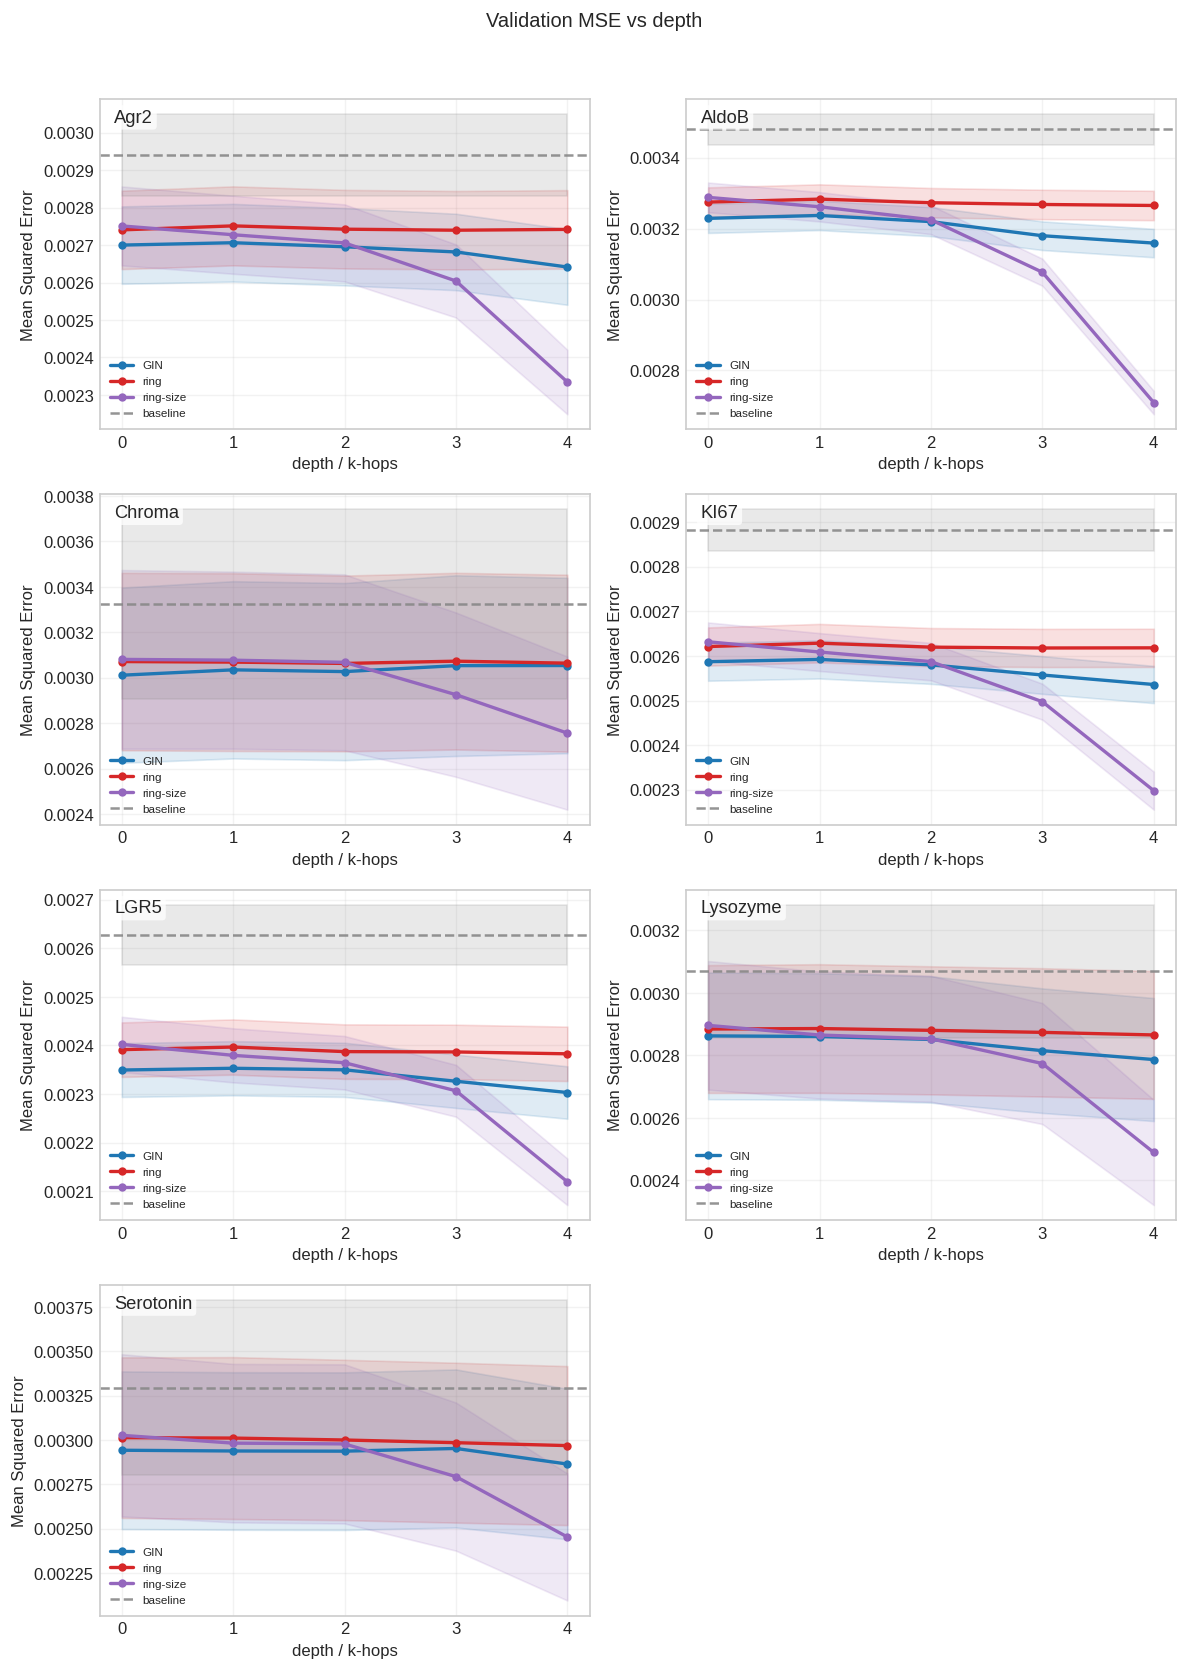

In [34]:
from src.plotting.depth_scan import plot_markerwise_metric_vs_depth, plot_all_aggregates_metric_vs_depth

plt.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

family_colors = {
    "GIN": "#1f77b4",
    # "GIN+degree": "#e377c2",
    "ring":      "#d62728",
    "ring-size": "#9467bd",
    "ring-size (no center)":       "#ff7f0e",
}


family_order = [
    "GIN",
    # "GIN+degree",
    "ring",
    "ring-size",
    "ring-size (no center)",
]


fig, axes = plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=depths,
    marker_names=marker_names,
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Validation MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "validation_mse_markerwise_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/permutation_tests/after_cleanup_rest_targets-0_features-1_depths-0-1-2-3-4_20260702_150617/figures/validation_mse_all_nodes_vs_depth.pdf


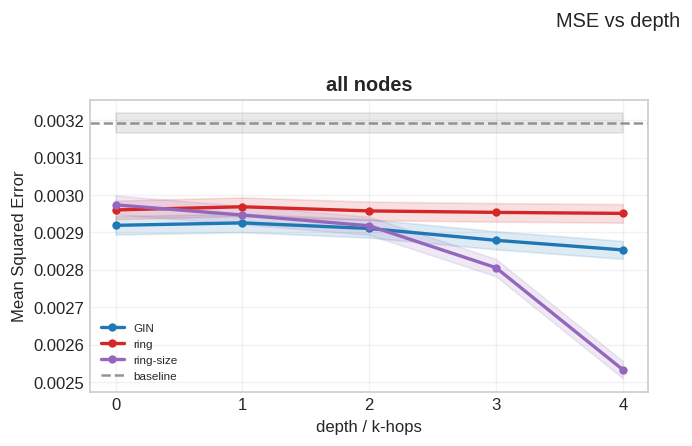

In [35]:
fig, axes = plot_all_aggregates_metric_vs_depth(
    eval_results,
    depths,
    aggregate_keys=("all_nodes",),
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "validation_mse_all_nodes_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/permutation_tests/after_cleanup_rest_targets-0_features-1_depths-0-1-2-3-4_20260702_150617/figures/validation_nll_markerwise_vs_depth.pdf


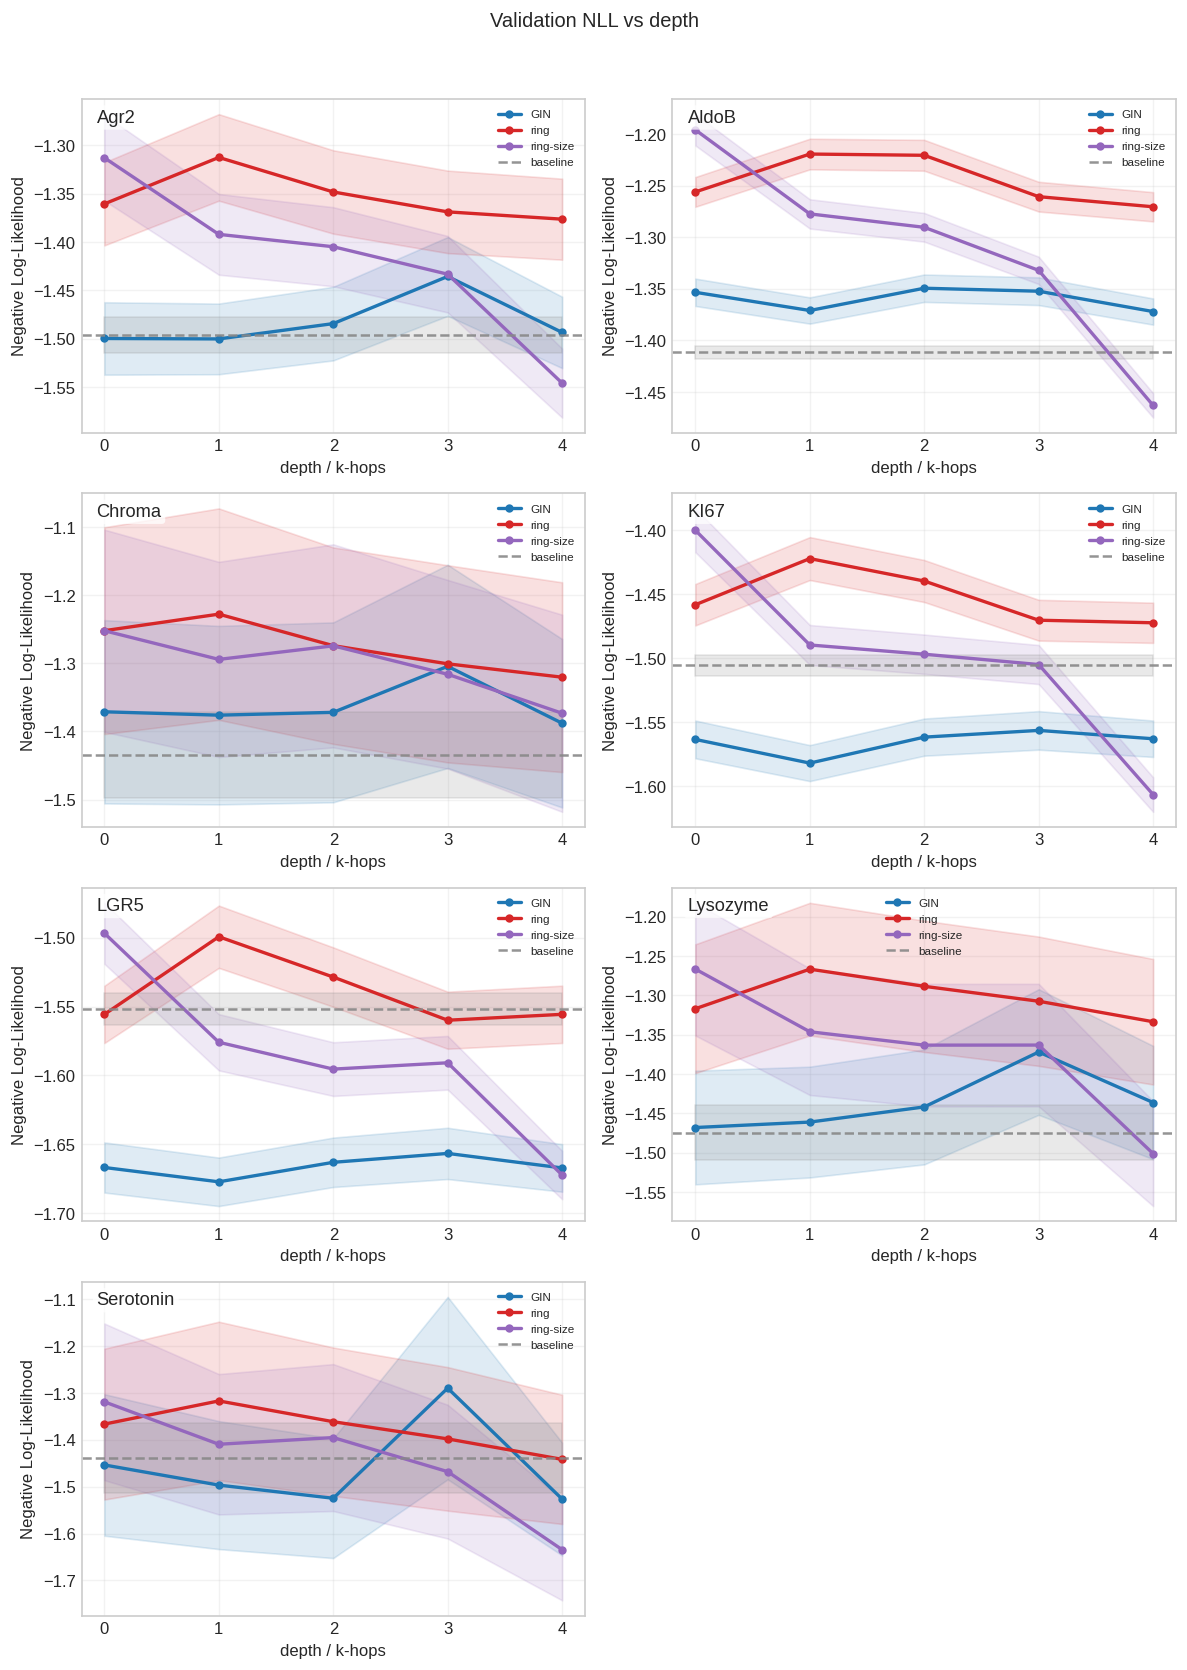

In [36]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=depths,
    marker_names=marker_names,
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Validation NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "validation_nll_markerwise_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/permutation_tests/after_cleanup_rest_targets-0_features-1_depths-0-1-2-3-4_20260702_150617/figures/validation_nll_all_nodes_vs_depth.pdf


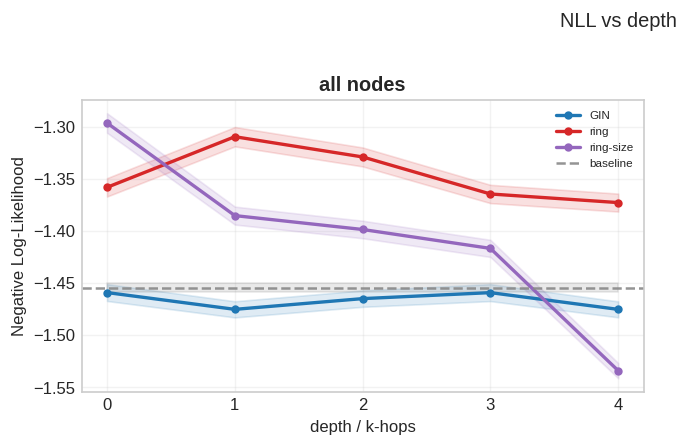

In [37]:
fig, axes = plot_all_aggregates_metric_vs_depth(
    eval_results,
    depths,
    aggregate_keys=("all_nodes",),
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "validation_nll_all_nodes_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/permutation_tests/after_cleanup_rest_targets-0_features-1_depths-0-1-2-3-4_20260702_150617/figures/uncertainty_error_correlation_markerwise_vs_depth.pdf


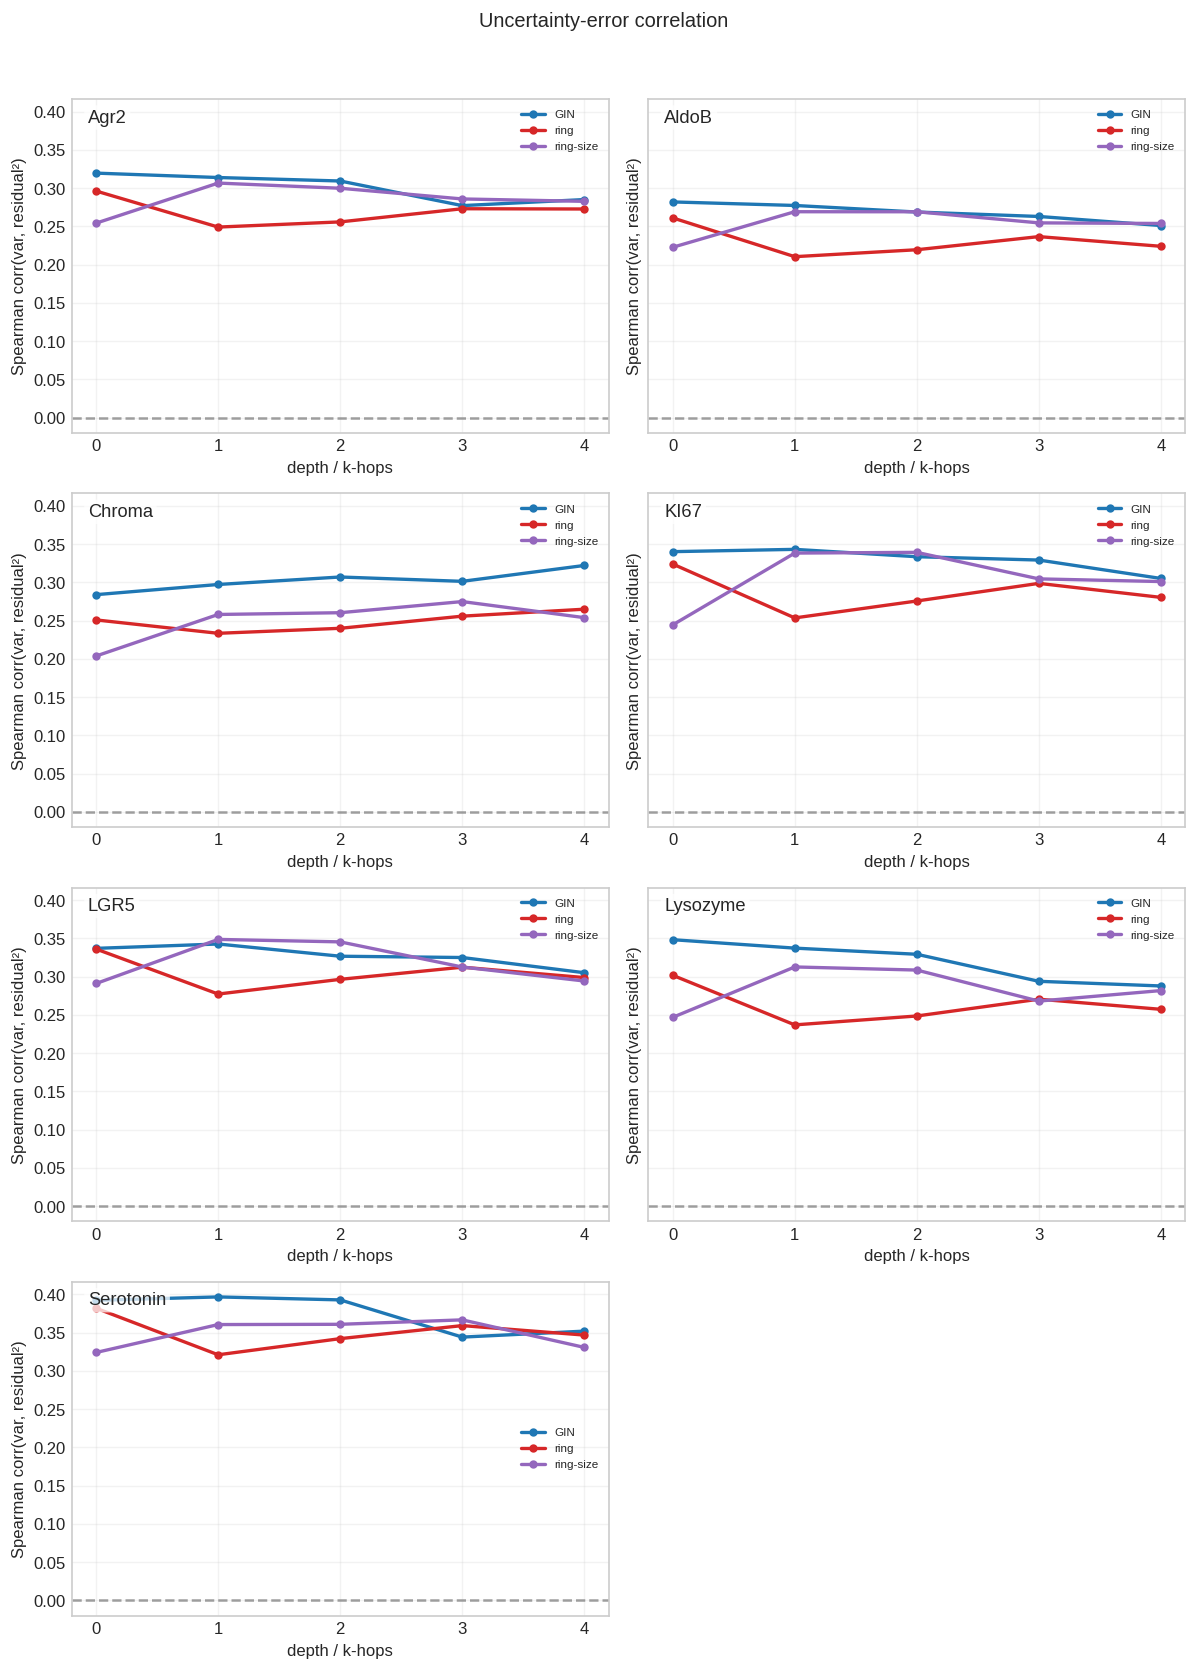

In [38]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=depths,
    marker_names=marker_names,
    metric_key="rho_marker",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation",
    family_order=family_order,
    family_colors=family_colors,
    sharey=True,
)
save_mpl_figure(fig, "uncertainty_error_correlation_markerwise_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/permutation_tests/after_cleanup_rest_targets-0_features-1_depths-0-1-2-3-4_20260702_150617/figures/uncertainty_error_correlation_all_nodes_vs_depth.pdf


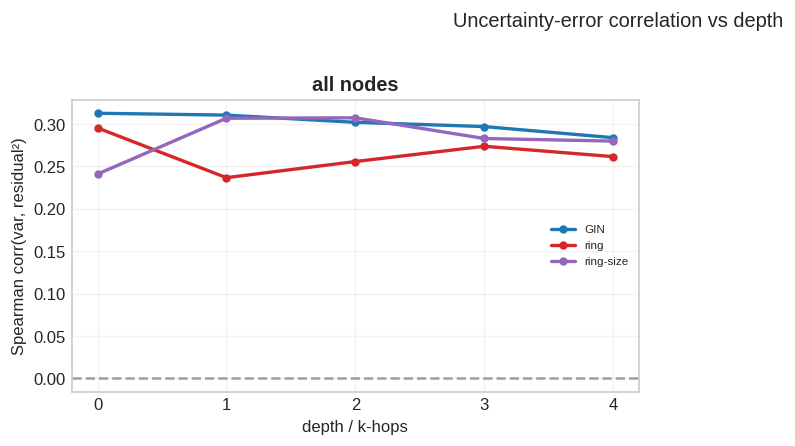

In [39]:
fig, axes = plot_all_aggregates_metric_vs_depth(
    eval_results,
    depths,
    aggregate_keys=("all_nodes",),
    metric_key="rho",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "uncertainty_error_correlation_all_nodes_vs_depth")
plt.show()


In [40]:
MARKERWISE_MODEL_METRICS = [
    "mse_model",
    "sem_mse_model",
    "var_model",
    "sem_var_model",
    "nll_model",
    "sem_nll_model",
    "rho_marker",
    "pval_marker",
    "n_pos_corr",
]
MARKERWISE_BASELINE_METRICS = [
    "mse_base",
    "sem_mse_base",
    "var_base",
    "nll_base",
    "sem_nll_base",
]
GLOBAL_METRICS = ["rho_global", "pval_global"]


def summarize_results(results, *, depths):
    rows = []
    for family, res in results.items():
        for depth_idx, depth in enumerate(depths):
            rows.append({
                "family": family,
                "depth": int(depth),
                "mse_all_nodes": float(res["aggregate"]["all_nodes"]["mse_model"][depth_idx]),
                "sem_mse_all_nodes": float(res["aggregate"]["all_nodes"]["sem_mse_model"][depth_idx]),
                "mse_base_all_nodes": float(res["aggregate"]["all_nodes"]["mse_base"][depth_idx]),
                "sem_mse_base_all_nodes": float(res["aggregate"]["all_nodes"]["sem_mse_base"][depth_idx]),
                "nll_all_nodes": float(res["aggregate"]["all_nodes"]["nll_model"][depth_idx]),
                "sem_nll_all_nodes": float(res["aggregate"]["all_nodes"]["sem_nll_model"][depth_idx]),
                "nll_base_all_nodes": float(res["aggregate"]["all_nodes"]["nll_base"][depth_idx]),
                "sem_nll_base_all_nodes": float(res["aggregate"]["all_nodes"]["sem_nll_base"][depth_idx]),
                "rho_all_nodes": float(res["aggregate"]["all_nodes"]["rho"][depth_idx]),
                "pval_all_nodes": float(res["aggregate"]["all_nodes"]["pval"][depth_idx]),
            })
    return pd.DataFrame(rows)


def flatten_markerwise_results(results, *, depths, marker_names_in):
    rows = []
    for family, res in results.items():
        for depth_idx, depth in enumerate(depths):
            for marker_idx, marker_name in enumerate(marker_names_in):
                row = {
                    "family": family,
                    "depth": int(depth),
                    "marker_index": int(marker_idx),
                    "marker": marker_name,
                }
                for metric in MARKERWISE_MODEL_METRICS:
                    if metric in res:
                        row[metric] = float(np.asarray(res[metric])[depth_idx, marker_idx])
                for metric in MARKERWISE_BASELINE_METRICS:
                    if metric in res:
                        row[metric] = float(np.asarray(res[metric])[marker_idx])
                rows.append(row)
    return pd.DataFrame(rows)


def flatten_aggregate_results(results, *, depths):
    rows = []
    for family, res in results.items():
        for aggregate_name, aggregate_metrics in res["aggregate"].items():
            for depth_idx, depth in enumerate(depths):
                row = {
                    "family": family,
                    "aggregate": aggregate_name,
                    "depth": int(depth),
                }
                for metric, values in aggregate_metrics.items():
                    row[metric] = float(np.asarray(values)[depth_idx])
                rows.append(row)
    return pd.DataFrame(rows)


def flatten_global_results(results, *, depths):
    rows = []
    for family, res in results.items():
        for depth_idx, depth in enumerate(depths):
            row = {"family": family, "depth": int(depth)}
            for metric in GLOBAL_METRICS:
                if metric in res:
                    row[metric] = float(np.asarray(res[metric])[depth_idx])
            rows.append(row)
    return pd.DataFrame(rows)


summary_df = summarize_results(eval_results, depths=depths)
markerwise_results_df = flatten_markerwise_results(
    eval_results,
    depths=depths,
    marker_names_in=marker_names,
)
aggregate_results_df = flatten_aggregate_results(eval_results, depths=depths)
global_results_df = flatten_global_results(eval_results, depths=depths)
training_summary_df = pd.DataFrame(param_rows)

summary_df.sort_values(["family", "depth"]).head(20)


,family,depth,mse_all_nodes,sem_mse_all_nodes,mse_base_all_nodes,sem_mse_base_all_nodes,nll_all_nodes,sem_nll_all_nodes,nll_base_all_nodes,sem_nll_base_all_nodes,rho_all_nodes,pval_all_nodes
0,GIN,0,0.002919,0.000025,0.003193,0.000026,-1.459373,0.008104,-1.454513,0.004122,0.312828,0.0
1,GIN,1,0.002926,0.000025,0.003193,0.000026,-1.475502,0.007777,-1.454513,0.004122,0.310639,0.0
2,GIN,2,0.002911,0.000024,0.003193,0.000026,-1.465190,0.007913,-1.454513,0.004122,0.302121,0.0
3,GIN,3,0.002879,0.000024,0.003193,0.000026,-1.459443,0.008159,-1.454513,0.004122,0.297098,0.0
4,GIN,4,0.002853,0.000024,0.003193,0.000026,-1.475526,0.007664,-1.454513,0.004122,0.284005,0.0
5,ring,0,0.002960,0.000025,0.003193,0.000026,-1.358243,0.008862,-1.454513,0.004122,0.295513,0.0
6,ring,1,0.002969,0.000025,0.003193,0.000026,-1.309603,0.009316,-1.454513,0.004122,0.236768,0.0
7,ring,2,0.002958,0.000025,0.003193,0.000026,-1.329046,0.009115,-1.454513,0.004122,0.255819,0.0
8,ring,3,0.002954,0.000025,0.003193,0.000026,-1.364640,0.008800,-1.454513,0.004122,0.273843,0.0
9,ring,4,0.002951,0.000025,0.003193,0.000026,-1.372910,0.008629,-1.454513,0.004122,0.261637,0.0


In [41]:
def save_joint_experiment(save_dir, config, results_by_experiment, notes=None):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(save_dir / "config.json", "w") as handle:
        json.dump(jsonable(config), handle, indent=2)

    with open(save_dir / "results.pkl", "wb") as handle:
        pickle.dump(results_by_experiment, handle)

    meta = {
        "timestamp": datetime.now().isoformat(),
        "notes": notes,
        "experiments": list(results_by_experiment.keys()),
    }
    with open(save_dir / "meta.json", "w") as handle:
        json.dump(jsonable(meta), handle, indent=2)

    print(f"Saved joint experiment -> {save_dir}")


In [42]:
RESULT_TABLE_FILES = {
    "summary_metrics": "summary_metrics.csv",
    "markerwise_metrics": "markerwise_metrics.csv",
    "aggregate_metrics": "aggregate_metrics.csv",
    "global_metrics": "global_metrics.csv",
    "training_summary": "training_summary.csv",
}

summary_df.to_csv(TABLES_DIR / RESULT_TABLE_FILES["summary_metrics"], index=False)
markerwise_results_df.to_csv(
    TABLES_DIR / RESULT_TABLE_FILES["markerwise_metrics"], index=False
)
aggregate_results_df.to_csv(
    TABLES_DIR / RESULT_TABLE_FILES["aggregate_metrics"], index=False
)
global_results_df.to_csv(
    TABLES_DIR / RESULT_TABLE_FILES["global_metrics"], index=False
)
training_summary_df.to_csv(
    TABLES_DIR / RESULT_TABLE_FILES["training_summary"], index=False
)

joint_config = {
    "created_at": RUN_TIMESTAMP,
    "experiment_group": EXPERIMENT_GROUP,
    "dataset": {
        "name": DATASET_NAME,
        "target_indices": TARGET_INDICES,
        "marker_names": list(marker_names),
    },
    "use_global_features": USE_GLOBAL_FEATURES,
    "filtering": {
        "timepoint_filter_mode": TIMEPOINT_FILTER_MODE,
        "day3p5_timepoint": DAY3P5_TIMEPOINT,
        "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
        "blacklisted_organoids": sorted(blacklist, key=str),
        "fill_missing_complexity": FILL_MISSING_COMPLEXITY,
        "apply_complexity_filter": APPLY_COMPLEXITY_FILTER,
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "complexity_min": COMPLEXITY_MIN,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
        "n_graphs_after_filtering": len(graphs),
    },
    "split": {
        "val_frac": VAL_FRAC,
        "split_seed": SPLIT_SEED,
        "forced_val_keys": sorted(FORCED_VAL_KEYS, key=str),
        "n_train_graphs": len(g_train),
        "n_val_graphs": len(g_val),
        "split_info": split_info,
    },
    "permutation": {
        "permute_targets": PERMUTE_TARGETS,
        "permute_features": PERMUTE_FEATURES,
        "permutation_seed": PERMUTATION_SEED,
    },
    "model": {
        "families": list(trained_model_families.keys()),
        "depths": depths.tolist(),
        "hidden_dim": base_hidden_dim,
        "dropout": base_dropout,
        "norm": base_norm,
        "k_max": K_MAX,
        "global_dim": global_dim,
    },
    "training": {
        "loss_name": cfg.loss_name,
        "lr": cfg.lr,
        "batch_size": cfg.batch_size,
        "max_epochs": cfg.max_epochs,
        "patience": cfg.patience,
        "num_workers": cfg.num_workers,
    },
    "outputs": {
        "save_dir": SAVE_DIR,
        "figures_dir": FIGURES_DIR,
        "tables_dir": TABLES_DIR,
        "result_tables": RESULT_TABLE_FILES,
        "results_pickle": "results.pkl",
    },
}

results_by_experiment = {
    "eval_results": eval_results,
    "training_logs": param_rows,
    "summary_table": summary_df.to_dict(orient="records"),
    "markerwise_metrics": markerwise_results_df.to_dict(orient="records"),
    "aggregate_metrics": aggregate_results_df.to_dict(orient="records"),
    "global_metrics": global_results_df.to_dict(orient="records"),
    "training_summary": training_summary_df.to_dict(orient="records"),
}

save_joint_experiment(
    save_dir=SAVE_DIR,
    config=joint_config,
    results_by_experiment=results_by_experiment,
    notes="Compare model behavior when trained and evaluated on permuted graphs.",
)

with open(SAVE_DIR / "settings.json", "w") as handle:
    json.dump(jsonable(joint_config), handle, indent=2)

print(f"Saved figures, tables, settings, and results to {SAVE_DIR}")


Saved joint experiment -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/permutation_tests/after_cleanup_rest_targets-0_features-1_depths-0-1-2-3-4_20260702_150617
Saved figures, tables, settings, and results to /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/permutation_tests/after_cleanup_rest_targets-0_features-1_depths-0-1-2-3-4_20260702_150617
